In [13]:
# =========================
# Import libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# =========================
# 1. Load and combine dataset
# =========================
path = "/content/"
all_files = glob.glob(path + "/*.csv")

dfs = []
for file in all_files:
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

# Convert datetime
if "Date (LT)" in df.columns:
    date_col = "Date (LT)"
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
else:
    raise ValueError("No valid date column found")

# Ensure PM2.5 concentration column
df['NowCast Conc.'] = pd.to_numeric(df['NowCast Conc.'], errors='coerce')
df = df.dropna(subset=['NowCast Conc.', date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)

# =========================
# 2. PM2.5 → AQI Category
# =========================
def pm25_to_aqi_category(pm25):
    if pm25 <= 50:
        return "Good"
    elif pm25 <= 100:
        return "Moderate"
    elif pm25 <= 150:
        return "Unhealthy for Sensitive"
    elif pm25 <= 200:
        return "Unhealthy"
    elif pm25 <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df['AQI_Category'] = df['NowCast Conc.'].apply(pm25_to_aqi_category)

# =========================
# 3. Feature Engineering
# =========================
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['Day'] = df[date_col].dt.day
df['Weekday'] = df[date_col].dt.weekday
df['DayOfYear'] = df[date_col].dt.dayofyear

# Lag features (previous pollution levels)
for lag in [1, 2, 3, 7, 14]:
    df[f'PM_Lag_{lag}'] = df['NowCast Conc.'].shift(lag)

# Rolling mean features (smoothed pollution trends)
for window in [3, 7, 14]:
    df[f'PM_Roll_{window}'] = df['NowCast Conc.'].rolling(window=window).mean().shift(1)

# Drop rows with NaNs created by lags/rolling
df = df.dropna().reset_index(drop=True)

# =========================
# 4. Prepare X, y
# =========================
feature_cols = [
    'Year', 'Month', 'Day', 'Weekday', 'DayOfYear'
] + [f'PM_Lag_{lag}' for lag in [1,2,3,7,14]] + [f'PM_Roll_{w}' for w in [3,7,14]]

X = df[feature_cols]
y = df['AQI_Category']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 5. Split data (stratified)
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# 6. Define models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, class_weight="balanced"),
    "SVM": SVC(kernel='rbf', probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.05, max_depth=6, n_estimators=300, eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(200,100), max_iter=2000, early_stopping=True, random_state=42)
}

# =========================
# 7. Train & Evaluate
# =========================
results = []
reports = {}  # Store classification reports

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val) if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="weighted")

    if y_proba is not None and y_proba.shape[1] > 1:
        roc = roc_auc_score(y_val, y_proba, multi_class="ovr")
    else:
        roc = None

    results.append([name, acc, f1, roc])

    # Save classification report as DataFrame
    report_dict = classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True)
    reports[name] = pd.DataFrame(report_dict).transpose()

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC-AUC Score:", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred, target_names=le.classes_))

# =========================
# 7c. Save Confusion Matrices Separately
# =========================
for name, model in models.items():
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"confusion_matrix_{name.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.close()

# =========================
# 8. Model Comparison
# =========================
result_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-Score", "ROC-AUC"]).sort_values(by="F1-Score", ascending=False)
print("\n\nModel Comparison (Validation Set):\n", result_df)

# =========================
# 9. Save Classification Reports as CSV
# =========================
for name, report_df in reports.items():
    report_df.to_csv(f"classification_report_{name.replace(' ', '_')}.csv")

print("\nClassification reports saved as CSV files.")

# =========================
# 10. Final Test Evaluation
# =========================
best_model_name = result_df.iloc[0, 0]
best_model = models[best_model_name]
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

print(f"\n=== Final Test Evaluation ({best_model_name}) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
if y_test_proba is not None and y_test_proba.shape[1] > 1:
    print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba, multi_class="ovr"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))



=== Logistic Regression ===
Accuracy: 0.7556134070940449
F1 Score: 0.7535571653029808
ROC-AUC Score: 0.9388343068874533
Confusion Matrix:
 [[1157    0  122    4    4    1]
 [   0   27    0    1    0    5]
 [ 201    1  537    9  114    1]
 [   3    0    4  194   26   48]
 [  12    0   46   79  272    5]
 [   3   32    2   27    1  135]]
                         precision    recall  f1-score   support

                   Good       0.84      0.90      0.87      1288
              Hazardous       0.45      0.82      0.58        33
               Moderate       0.76      0.62      0.68       863
              Unhealthy       0.62      0.71      0.66       275
Unhealthy for Sensitive       0.65      0.66      0.65       414
         Very Unhealthy       0.69      0.68      0.68       200

               accuracy                           0.76      3073
              macro avg       0.67      0.73      0.69      3073
           weighted avg       0.76      0.76      0.75      3073


=== Ran

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:57:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
Accuracy: 0.8333875691506671
F1 Score: 0.8315145623729194
ROC-AUC Score: 0.9714113775296266
Confusion Matrix:
 [[1203    0   79    3    3    0]
 [   0   14    0    1    0   18]
 [ 115    0  700    5   40    3]
 [   1    0    8  181   49   36]
 [   5    0   66   43  295    5]
 [   2    2    2   25    1  168]]
                         precision    recall  f1-score   support

                   Good       0.91      0.93      0.92      1288
              Hazardous       0.88      0.42      0.57        33
               Moderate       0.82      0.81      0.81       863
              Unhealthy       0.70      0.66      0.68       275
Unhealthy for Sensitive       0.76      0.71      0.74       414
         Very Unhealthy       0.73      0.84      0.78       200

               accuracy                           0.83      3073
              macro avg       0.80      0.73      0.75      3073
           weighted avg       0.83      0.83      0.83      3073


=== MLP ===
Accurac

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# =========================
# 1. Load and combine dataset
# =========================
path = "/content/"
all_files = glob.glob(path + "/*.csv")

dfs = []
for file in all_files:
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

# Convert datetime
if "Date (LT)" in df.columns:
    date_col = "Date (LT)"
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
else:
    raise ValueError("No valid date column found")

# Ensure PM2.5 concentration column
df['NowCast Conc.'] = pd.to_numeric(df['NowCast Conc.'], errors='coerce')
df = df.dropna(subset=['NowCast Conc.', date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)

# =========================
# 2. PM2.5 → AQI Category
# =========================
def pm25_to_aqi_category(pm25):
    if pm25 <= 50:
        return "Good"
    elif pm25 <= 100:
        return "Moderate"
    elif pm25 <= 150:
        return "Unhealthy for Sensitive"
    elif pm25 <= 200:
        return "Unhealthy"
    elif pm25 <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df['AQI_Category'] = df['NowCast Conc.'].apply(pm25_to_aqi_category)

# =========================
# 3. Feature Engineering
# =========================
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['Day'] = df[date_col].dt.day
df['Weekday'] = df[date_col].dt.weekday
df['DayOfYear'] = df[date_col].dt.dayofyear

# Lag features (previous pollution levels)
for lag in [1, 2, 3, 7, 14]:
    df[f'PM_Lag_{lag}'] = df['NowCast Conc.'].shift(lag)

# Rolling mean features (smoothed pollution trends)
for window in [3, 7, 14]:
    df[f'PM_Roll_{window}'] = df['NowCast Conc.'].rolling(window=window).mean().shift(1)

# Drop rows with NaNs created by lags/rolling
df = df.dropna().reset_index(drop=True)

# =========================
# 4. Prepare X, y
# =========================
feature_cols = [
    'Year', 'Month', 'Day', 'Weekday', 'DayOfYear'
] + [f'PM_Lag_{lag}' for lag in [1,2,3,7,14]] + [f'PM_Roll_{w}' for w in [3,7,14]]

X = df[feature_cols]
y = df['AQI_Category']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 5. Split data (stratified)
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# 6. Define models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, class_weight="balanced"),
    "SVM": SVC(kernel='rbf', probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.05, max_depth=6, n_estimators=300, eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(200,100), max_iter=2000, early_stopping=True, random_state=42)
}

# =========================
# 7. Train & Evaluate
# =========================
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val) if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="weighted")

    if y_proba is not None and y_proba.shape[1] > 1:
        roc = roc_auc_score(y_val, y_proba, multi_class="ovr")
    else:
        roc = None

    results.append([name, acc, f1, roc])

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC-AUC Score:", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred, target_names=le.classes_))

# =========================
# 8. Model Comparison
# =========================
result_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-Score", "ROC-AUC"]).sort_values(by="F1-Score", ascending=False)
print("\n\nModel Comparison (Validation Set):\n", result_df)

# =========================
# 9. Final Test Evaluation
# =========================
best_model_name = result_df.iloc[0, 0]
best_model = models[best_model_name]
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

print(f"\n=== Final Test Evaluation ({best_model_name}) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
if y_test_proba is not None and y_test_proba.shape[1] > 1:
    print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba, multi_class="ovr"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))



=== Logistic Regression ===
Accuracy: 0.7556134070940449
F1 Score: 0.7535571653029808
ROC-AUC Score: 0.9388343068874533
Confusion Matrix:
 [[1157    0  122    4    4    1]
 [   0   27    0    1    0    5]
 [ 201    1  537    9  114    1]
 [   3    0    4  194   26   48]
 [  12    0   46   79  272    5]
 [   3   32    2   27    1  135]]
                         precision    recall  f1-score   support

                   Good       0.84      0.90      0.87      1288
              Hazardous       0.45      0.82      0.58        33
               Moderate       0.76      0.62      0.68       863
              Unhealthy       0.62      0.71      0.66       275
Unhealthy for Sensitive       0.65      0.66      0.65       414
         Very Unhealthy       0.69      0.68      0.68       200

               accuracy                           0.76      3073
              macro avg       0.67      0.73      0.69      3073
           weighted avg       0.76      0.76      0.75      3073


=== Ran

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:29:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
Accuracy: 0.8333875691506671
F1 Score: 0.8315145623729194
ROC-AUC Score: 0.9714113775296266
Confusion Matrix:
 [[1203    0   79    3    3    0]
 [   0   14    0    1    0   18]
 [ 115    0  700    5   40    3]
 [   1    0    8  181   49   36]
 [   5    0   66   43  295    5]
 [   2    2    2   25    1  168]]
                         precision    recall  f1-score   support

                   Good       0.91      0.93      0.92      1288
              Hazardous       0.88      0.42      0.57        33
               Moderate       0.82      0.81      0.81       863
              Unhealthy       0.70      0.66      0.68       275
Unhealthy for Sensitive       0.76      0.71      0.74       414
         Very Unhealthy       0.73      0.84      0.78       200

               accuracy                           0.83      3073
              macro avg       0.80      0.73      0.75      3073
           weighted avg       0.83      0.83      0.83      3073


=== MLP ===
Accurac

In [12]:
# =========================
# Import libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# =========================
# 1. Load and combine dataset
# =========================
path = "/content/"
all_files = glob.glob(path + "/*.csv")

dfs = []
for file in all_files:
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

# Convert datetime
if "Date (LT)" in df.columns:
    date_col = "Date (LT)"
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
else:
    raise ValueError("No valid date column found")

# Ensure PM2.5 concentration column
df['NowCast Conc.'] = pd.to_numeric(df['NowCast Conc.'], errors='coerce')
df = df.dropna(subset=['NowCast Conc.', date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)

# =========================
# 2. PM2.5 → AQI Category
# =========================
def pm25_to_aqi_category(pm25):
    if pm25 <= 50:
        return "Good"
    elif pm25 <= 100:
        return "Moderate"
    elif pm25 <= 150:
        return "Unhealthy for Sensitive"
    elif pm25 <= 200:
        return "Unhealthy"
    elif pm25 <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df['AQI_Category'] = df['NowCast Conc.'].apply(pm25_to_aqi_category)

# =========================
# 3. Feature Engineering
# =========================
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['Day'] = df[date_col].dt.day
df['Weekday'] = df[date_col].dt.weekday
df['DayOfYear'] = df[date_col].dt.dayofyear

# Lag features (previous pollution levels)
for lag in [1, 2, 3, 7, 14]:
    df[f'PM_Lag_{lag}'] = df['NowCast Conc.'].shift(lag)

# Rolling mean features (smoothed pollution trends)
for window in [3, 7, 14]:
    df[f'PM_Roll_{window}'] = df['NowCast Conc.'].rolling(window=window).mean().shift(1)

# Drop rows with NaNs created by lags/rolling
df = df.dropna().reset_index(drop=True)

# =========================
# 4. Prepare X, y
# =========================
feature_cols = [
    'Year', 'Month', 'Day', 'Weekday', 'DayOfYear'
] + [f'PM_Lag_{lag}' for lag in [1,2,3,7,14]] + [f'PM_Roll_{w}' for w in [3,7,14]]

X = df[feature_cols]
y = df['AQI_Category']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 5. Split data (stratified)
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# 6. Define models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, class_weight="balanced"),
    "SVM": SVC(kernel='rbf', probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.05, max_depth=6, n_estimators=300, eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(200,100), max_iter=2000, early_stopping=True, random_state=42)
}

# =========================
# 7. Train & Evaluate
# =========================
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val) if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="weighted")

    if y_proba is not None and y_proba.shape[1] > 1:
        roc = roc_auc_score(y_val, y_proba, multi_class="ovr")
    else:
        roc = None

    results.append([name, acc, f1, roc])

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC-AUC Score:", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred, target_names=le.classes_))

# =========================
# 7c. Save Confusion Matrices Separately
# =========================
for name, model in models.items():
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"confusion_matrix_{name.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.close()

# =========================
# 8. Model Comparison
# =========================
result_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-Score", "ROC-AUC"]).sort_values(by="F1-Score", ascending=False)
print("\n\nModel Comparison (Validation Set):\n", result_df)

# =========================
# 9. Final Test Evaluation
# =========================
best_model_name = result_df.iloc[0, 0]
best_model = models[best_model_name]
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

print(f"\n=== Final Test Evaluation ({best_model_name}) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
if y_test_proba is not None and y_test_proba.shape[1] > 1:
    print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba, multi_class="ovr"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))



=== Logistic Regression ===
Accuracy: 0.7556134070940449
F1 Score: 0.7535571653029808
ROC-AUC Score: 0.9388343068874533
Confusion Matrix:
 [[1157    0  122    4    4    1]
 [   0   27    0    1    0    5]
 [ 201    1  537    9  114    1]
 [   3    0    4  194   26   48]
 [  12    0   46   79  272    5]
 [   3   32    2   27    1  135]]
                         precision    recall  f1-score   support

                   Good       0.84      0.90      0.87      1288
              Hazardous       0.45      0.82      0.58        33
               Moderate       0.76      0.62      0.68       863
              Unhealthy       0.62      0.71      0.66       275
Unhealthy for Sensitive       0.65      0.66      0.65       414
         Very Unhealthy       0.69      0.68      0.68       200

               accuracy                           0.76      3073
              macro avg       0.67      0.73      0.69      3073
           weighted avg       0.76      0.76      0.75      3073


=== Ran

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:37:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
Accuracy: 0.8333875691506671
F1 Score: 0.8315145623729194
ROC-AUC Score: 0.9714113775296266
Confusion Matrix:
 [[1203    0   79    3    3    0]
 [   0   14    0    1    0   18]
 [ 115    0  700    5   40    3]
 [   1    0    8  181   49   36]
 [   5    0   66   43  295    5]
 [   2    2    2   25    1  168]]
                         precision    recall  f1-score   support

                   Good       0.91      0.93      0.92      1288
              Hazardous       0.88      0.42      0.57        33
               Moderate       0.82      0.81      0.81       863
              Unhealthy       0.70      0.66      0.68       275
Unhealthy for Sensitive       0.76      0.71      0.74       414
         Very Unhealthy       0.73      0.84      0.78       200

               accuracy                           0.83      3073
              macro avg       0.80      0.73      0.75      3073
           weighted avg       0.83      0.83      0.83      3073


=== MLP ===
Accurac

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2237
[LightGBM] [Info] Number of data points in the train set: 14340, number of used features: 13
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


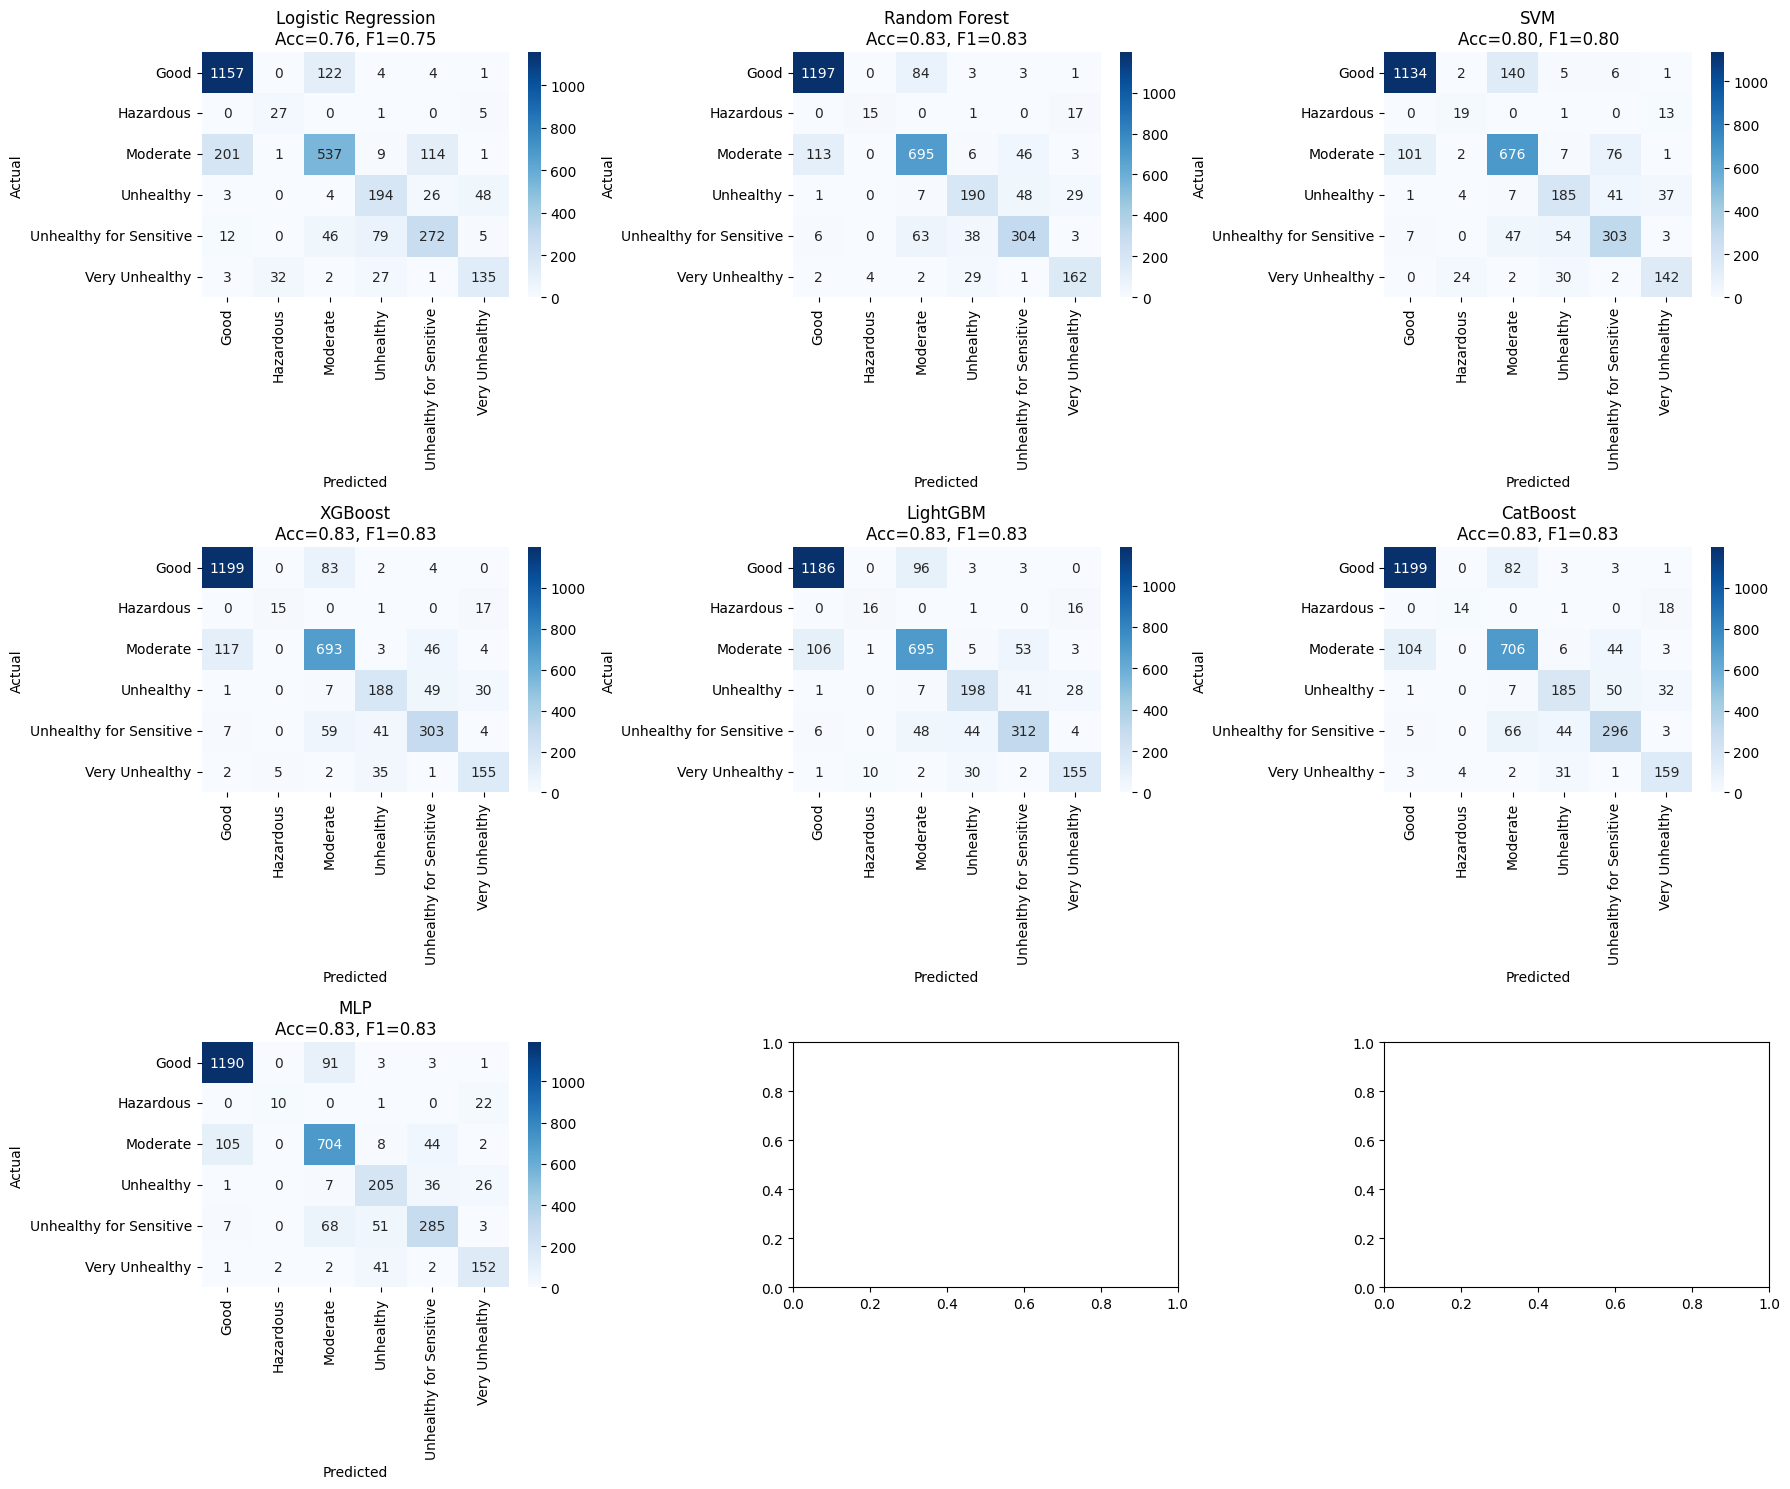



Model Comparison (Validation Set):
                  Model  Accuracy  F1-Score   ROC-AUC
4             LightGBM  0.833713  0.833355  0.969067
1        Random Forest  0.834038  0.832766  0.971267
5             CatBoost  0.832737  0.831422  0.971348
3              XGBoost  0.830784  0.829478  0.972080
6                  MLP  0.828506  0.827036  0.967430
2                  SVM  0.800195  0.802243  0.963888
0  Logistic Regression  0.755613  0.753557  0.938834


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Final Test Evaluation (LightGBM) ===
Accuracy: 0.8295380611581002
F1 Score: 0.8294673036490694
ROC-AUC Score: 0.9654870561719865
Confusion Matrix:
 [[1188    0   98    0    2    0]
 [   0   19    1    1    2   10]
 [ 102    0  686    6   66    4]
 [   3    2    6  194   46   24]
 [   1    0   49   42  314    9]
 [   1    8    4   32    5  149]]
                         precision    recall  f1-score   support

                   Good       0.92      0.92      0.92      1288
              Hazardous       0.66      0.58      0.61        33
               Moderate       0.81      0.79      0.80       864
              Unhealthy       0.71      0.71      0.71       275
Unhealthy for Sensitive       0.72      0.76      0.74       415
         Very Unhealthy       0.76      0.75      0.75       199

               accuracy                           0.83      3074
              macro avg       0.76      0.75      0.76      3074
           weighted avg       0.83      0.83      0.83      3

In [11]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

# =========================
# 1. Load dataset
# =========================
path = "/content/"
all_files = glob.glob(path + "/*.csv")

dfs = []
for file in all_files:
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

# Convert datetime
date_col = "Date (LT)"
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# Ensure PM2.5 concentration column
df['NowCast Conc.'] = pd.to_numeric(df['NowCast Conc.'], errors='coerce')
df = df.dropna(subset=['NowCast Conc.', date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)

# =========================
# 2. PM2.5 → AQI Category
# =========================
def pm25_to_aqi_category(pm25):
    if pm25 <= 50:
        return "Good"
    elif pm25 <= 100:
        return "Moderate"
    elif pm25 <= 150:
        return "Unhealthy for Sensitive"
    elif pm25 <= 200:
        return "Unhealthy"
    elif pm25 <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df['AQI_Category'] = df['NowCast Conc.'].apply(pm25_to_aqi_category)

# =========================
# 3. Feature Engineering
# =========================
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['Day'] = df[date_col].dt.day
df['Weekday'] = df[date_col].dt.weekday
df['DayOfYear'] = df[date_col].dt.dayofyear

# Lag features
for lag in [1, 2, 3, 7, 14]:
    df[f'PM_Lag_{lag}'] = df['NowCast Conc.'].shift(lag)

# Rolling mean features
for window in [3, 7, 14]:
    df[f'PM_Roll_{window}'] = df['NowCast Conc.'].rolling(window=window).mean().shift(1)

# Drop NaNs from lag/rolling
df = df.dropna().reset_index(drop=True)

# =========================
# 4. Prepare X, y
# =========================
feature_cols = [
    'Year', 'Month', 'Day', 'Weekday', 'DayOfYear'
] + [f'PM_Lag_{lag}' for lag in [1,2,3,7,14]] + [f'PM_Roll_{w}' for w in [3,7,14]]

X = df[feature_cols]
y = df['AQI_Category']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 5. Split data
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# 6. Define Models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=25, random_state=42, class_weight="balanced"),
    "SVM": SVC(kernel='rbf', probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.05, max_depth=8, n_estimators=400, subsample=0.8,
                              colsample_bytree=0.8, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=-1, random_state=42, class_weight="balanced"),
    "CatBoost": CatBoostClassifier(iterations=400, learning_rate=0.05, depth=8, verbose=0, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), max_iter=2000, alpha=0.001, early_stopping=True, random_state=42)
}

# =========================
# 7. Train & Evaluate + Confusion Matrices
# =========================
results = []
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val) if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="weighted")
    roc = roc_auc_score(y_val, y_proba, multi_class="ovr") if y_proba is not None else None

    results.append([name, acc, f1, roc])

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[i])
    axes[i].set_title(f"{name}\nAcc={acc:.2f}, F1={f1:.2f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# =========================
# 8. Results Summary
# =========================
result_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-Score", "ROC-AUC"]).sort_values(by="F1-Score", ascending=False)
print("\n\nModel Comparison (Validation Set):\n", result_df)

# =========================
# 9. Final Test Evaluation on Best Model
# =========================
best_model_name = result_df.iloc[0, 0]
best_model = models[best_model_name]
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

print(f"\n=== Final Test Evaluation ({best_model_name}) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
if y_test_proba is not None and y_test_proba.shape[1] > 1:
    print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba, multi_class="ovr"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))



In [10]:
!pip install catboost

After the installation is complete, please run the code cell again.